# Uber Ride Data Analysis

## Introduction

This project analyzes Uber ride data to identify patterns in ride demand,
customer behavior, trip characteristics, and revenue.

### Key Questions

1. When is Uber demand highest?
2. Which days and hours generate the most rides?
3. What are the most popular pickup locations?
4. How does trip distance affect fare?
5. Which factors are associated with cancellations?


# Task One

## Data Loading and Initial Exploration

In this section, we load the dataset and examine its structure.

We will check:
- Number of rows and columns
- Column names
- Data types
- Missing values
- Duplicate records
- Basic descriptive statistics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats

In [2]:
df = pd.read_csv(r'C:\Users\MCHARO\Downloads\uber.csv\uber.csv')
df.head(10)

,trip_id,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,52:06.0,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,04:56.0,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,45:00.0,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,22:21.0,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,47:00.0,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
5,44470845,27:09.0,4.9,2011-02-12 02:27:09 UTC,-73.969019,40.755910,-73.969019,40.755910,1
6,48725865,04:00.0,24.5,2014-10-12 07:04:00 UTC,-73.961447,40.693965,-73.871195,40.774297,5
7,44195482,52:00.0,2.5,2012-12-11 13:52:00 UTC,0.000000,0.000000,0.000000,0.000000,1
8,15822268,32:00.0,9.7,2012-02-17 09:32:00 UTC,-73.975187,40.745767,-74.002720,40.743537,1
9,50611056,06:00.0,12.5,2012-03-29 19:06:00 UTC,-74.001065,40.741787,-73.963040,40.775012,1


# Data Exploration

In [3]:
print("Dataset Shape:", df.shape)
print(f"\nTotal Records: {len(df):,}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024 ** 2:.2f} MB")

Dataset Shape: (200000, 9)

Total Records: 200,000
Memory Usage: 19.46 MB


In [4]:
print("Column Names and Types:")
print(df.dtypes)
print("\nFirst 10 Rows:")
df.head()

Column Names and Types:
trip_id                int64
key                      str
fare_amount          float64
pickup_datetime          str
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object

First 10 Rows:


,trip_id,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,52:06.0,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,04:56.0,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,45:00.0,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,22:21.0,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,47:00.0,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [5]:
print("Basic Statistics:")
df.describe()

Basic Statistics:


,trip_id,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967153,40.767158,-73.963659,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


## Missing Value Analysis

In [6]:
print("Missing Values Analysis:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})

print(missing_df[missing_df['Missing_Count']> 0].sort_values('Missing_Count', ascending=False))
print(f"\nTotal Missing Values: {missing.sum():,}")

Missing Values Analysis:
                   Missing_Count  Percentage
dropoff_longitude              1      0.0005
dropoff_latitude               1      0.0005

Total Missing Values: 2


Drop Missing Values

In [7]:
df.dropna(inplace=True)

In [8]:
# Check Missing Values
print("Missing Values after cleaning:", df.isnull().sum())

Missing Values after cleaning: trip_id              0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64


# Checking Duplicate Values

In [9]:
# Check Number of Duplicates
print("Duplicates before cleaning:", df.duplicated().sum())

# Drop duplicate rows
df = df.drop_duplicates()

# Cross Checking
print("Duplicates after cleaning:", df.duplicated().sum())

# Save cleaned dataset


Duplicates before cleaning: 0
Duplicates after cleaning: 0


## Statistical Summary

In [10]:
df.describe()

,trip_id,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,1.999990e+05,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000
mean,2.771248e+07,11.359892,-72.527631,39.935881,-72.525292,39.923890,1.684543
std,1.601386e+07,9.901760,11.437815,7.720558,13.117408,6.794829,1.385995
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382534e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774524e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155535e+07,12.500000,-73.967154,40.767158,-73.963659,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [11]:
df.columns

Index(['trip_id', 'key', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count'],
      dtype='str')

## Business Questions to be Answered 

## 1. When is Uber demand highest?

In [12]:
df["pickup_datetime"] = pd.to_datetime(
    df["pickup_datetime"],
    errors="coerce",
    utc=True
)

df["hour"] = df["pickup_datetime"].dt.hour

hourly_demand = df.groupby("hour").size()
print(hourly_demand.sort_values(ascending=False).head(10))


hour
19    12605
18    12072
20    11755
21    11446
22    11023
13    10024
12     9924
23     9805
17     9758
14     9749
dtype: int64


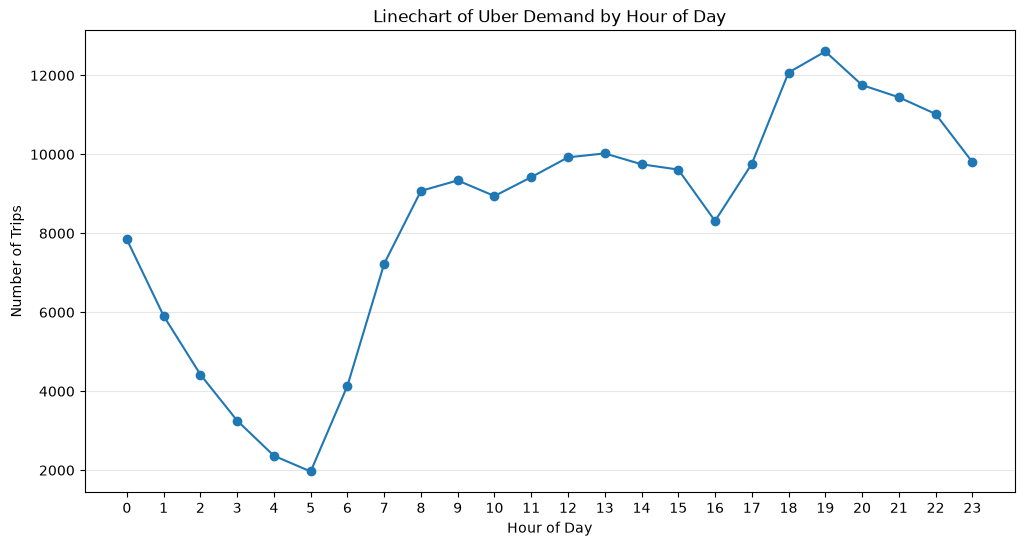

In [13]:
# Linechart
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["hour"] = df["pickup_datetime"].dt.hour

hourly_demand = df.groupby("hour").size()

plt.figure(figsize=(12,6))
plt.plot(hourly_demand.index, hourly_demand.values, marker="o")

plt.title("Linechart of Uber Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)

plt.show()

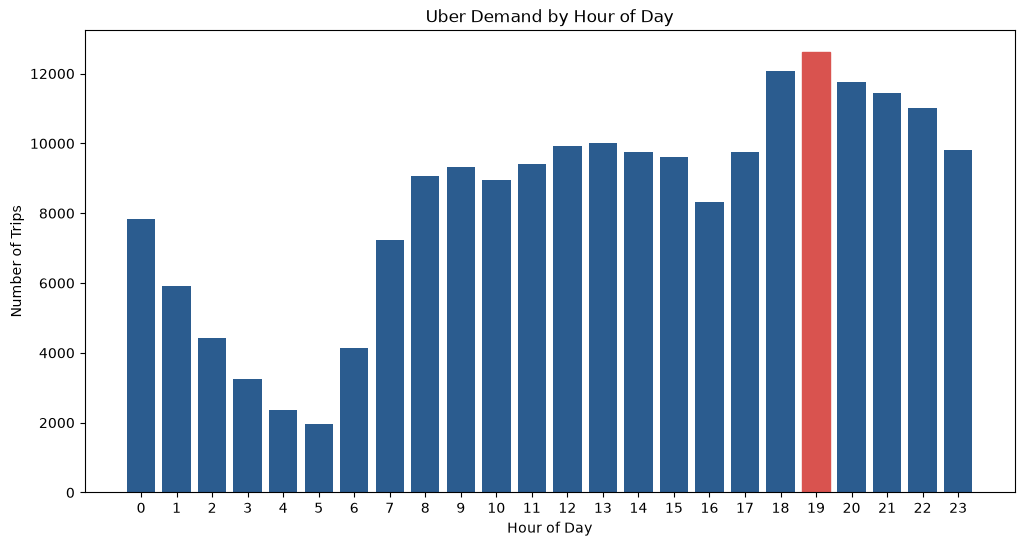

In [14]:
# Barchart
if 'hour' not in df.columns:
	df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce', utc=True)
	df['hour'] = df['pickup_datetime'].dt.hour

hourly_demand = df.groupby('hour').size().sort_index()

plt.figure(figsize=(12,6))
bars = plt.bar(hourly_demand.index, hourly_demand.values, color='#2b5c8f')
bars[19].set_color('#d9534f') #Highlights Most Uber Demand
plt.title("Uber Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(24))
plt.show()

## 🚗 Uber Demand by Hour

The chart shows a clear evening peak:

7 PM (19:00): 12,605 trips — highest demand

6 PM: ~12,100 trips

8 PM: ~11,700 trips

Demand is lowest around 5 AM

So the key EDA insight is:

Uber demand peaks at 7 PM, with 12,605 trips. Demand rises sharply from 5 PM and remains high through the evening.

 ## 2. Which days and hours generate the most rides?

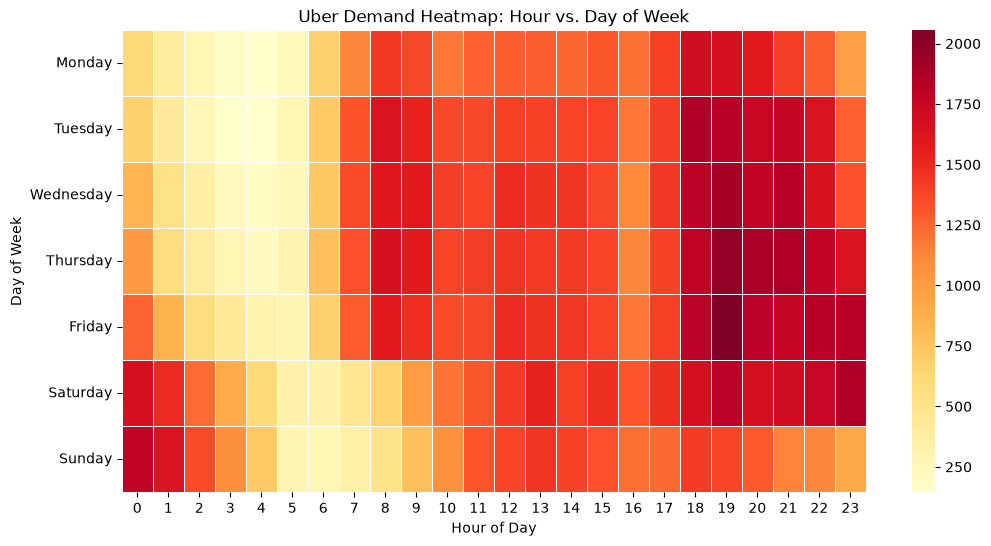

In [15]:
# Day of Week x Hour Heatmap

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce', utc=True)
df = df.dropna(subset=['pickup_datetime']).copy()

if 'hour' not in df.columns:
    df['hour'] = df['pickup_datetime'].dt.hour

df['day_of_week'] = df['pickup_datetime'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = df.pivot_table(index='day_of_week', columns='hour', aggfunc='size', fill_value=0).reindex(days_order)

# Plot
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidth=0.5)
plt.title("Uber Demand Heatmap: Hour vs. Day of Week")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

## Uber Demand by Hour and Day of the Week

The heatmap visualization (Hour of Day x Day of Week) is the best visualization to reveal deeper demand patterns beyond simple hourly aggregates.

A heatmap cross-references hourly trip volume against each day of the week, allowing you to instantly see whether the 7 PM peak is concentrated on weekdays (commuters) or weekends (nightlife).

It is noted that Uber rides are more common on Friday at 7 PM and least common on Monday at 5 AM.

## 3. What are the most popular pickup locations?

## Linegraph showing Uber Hourly Pickup Trends: Top 5 Location Clusters on NYC Core

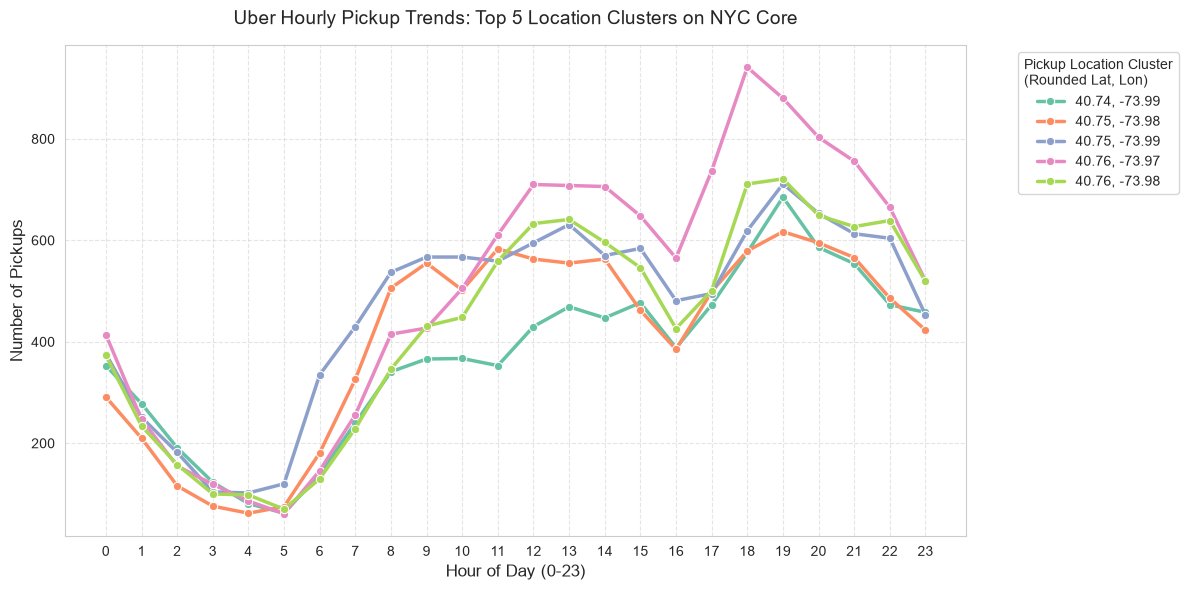

In [18]:
# Pickup_datetime is a datetime object
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')

# Filter for New York City and drop rows with invalid coordinate
valid_coords = df[
    (df['pickup_latitude'].between(40.68,40.85)) &
    (df['pickup_longitude'].between(-74.05, -73.90))
].dropna(subset=['pickup_longitude', 'pickup_longitude'])

# Round to 2 decimal places to cluster into approximate neighbourhood blocks
valid_coords['lat_round'] = valid_coords['pickup_latitude'].round(2)
valid_coords['lon_round'] = valid_coords['pickup_longitude'].round(2)

# Create a combined location label
valid_coords['location_cluster'] = (valid_coords['lat_round'].astype(str) + ", " + valid_coords['lon_round'].astype(str))

# Identify the top 5 location clustures by pickup volume
top_5_clustures = valid_coords['location_cluster'].value_counts().head(5).index.tolist()

# Filter the original dataframe to include only the data for these top 5 clusters
# Use the actual variable name created earlier in the notebook
if 'top_5_clusters' not in globals() and 'top_5_clustures' in globals():
    top_5_clusters = top_5_clustures

df_top_clusters = valid_coords[valid_coords['location_cluster'].isin(top_5_clusters)].copy()

# Add an 'hour' column for time series analysis
df_top_clusters = df_top_clusters['pickup_datetime'].dt.hour

# Group by hour and location, then count trips
# Rebuild the top-5 cluster dataframe if a previous edit overwrote it with a Series
top_5_cluster_list = globals().get("top_5_clusters", globals().get("top_5_clustures", []))
if not isinstance(df_top_clusters, pd.DataFrame):
    df_top_clusters = valid_coords[valid_coords["location_cluster"].isin(top_5_cluster_list)].copy()

# Make sure the hour column exists before grouping
if "hour" not in df_top_clusters.columns:
    df_top_clusters["hour"] = pd.to_datetime(df_top_clusters["pickup_datetime"], errors="coerce").dt.hour

hourly_pickups_top5 = (
    df_top_clusters.groupby(["hour", "location_cluster"])
    .size()
    .reset_index(name="trip_count")
    .sort_values(["location_cluster", "hour"])
    .reset_index(drop=True)
)
# Set the style
sns.set_style("whitegrid")
plt.figure(figsize=(12,6))

# Plot lines for each of the top 5 location clusters
hourly_pickups_top5 = hourly_pickups_top5.sort_values('hour')

# Lineplot
sns.lineplot(
    data = hourly_pickups_top5,
    x = 'hour',
    y = 'trip_count',
    hue = 'location_cluster',
    marker = 'o',
    markersize = 6,
    linewidth = 2.5,
    palette = 'Set2'
)

# Title and Labels
plt.title("Uber Hourly Pickup Trends: Top 5 Location Clusters on NYC Core", fontsize = 14, pad = 15)
plt.xlabel("Hour of Day (0-23)", fontsize = 12)
plt.ylabel("Number of Pickups", fontsize = 12)

# Customize X-axis ticks
plt.xticks(range(24))

# Add gridlines
plt.grid(True, linestyle = '--', alpha = 0.5)

# Legend
plt.legend(title = "Pickup Location Cluster\n(Rounded Lat, Lon)", bbox_to_anchor = (1.05, 1), loc = 'upper left')

# Optimize Layout
plt.tight_layout()

# Save plot
plt.savefig('uber_top5_hourly_pickups_line.png', dpi = 300)
plt.show()

A line graph is ideal for visualizing how pickup volumes at different locations change over time. Since we identified that demand is highest in the evening, this graph compares the hourly trends of the top 5 most popular geographic pickup clusters in NYC.

How to interpret this graph:
Location Trends: It allows us to compare whether different popular areas, such as the Garment District vs. Grand Central, share the same peak hours or have distinct demand patterns.

Synchronized Peaks: All top locations exhibit a dramatic rise in demand starting from the morning commute and culminate in a shared, massive spike during the 5 PM–10 PM period, confirming that the evening peak is a city-wide phenomenon, not localized to a single neighborhood.

Early Morning: The graph clearly shows all locations reaching their lowest demand between 2 AM and 5 AM.

This visualization answers not just where demand is high, but how that geography is dynamic throughout the day.

# Pickup Density Visualization

This measures how many ride pickups happen within a specific area like a street per square kilometer over a given amount of time.

It groups nearby rides together to highlight demand and concentration such as:

**(i) High Density / Hotspots:** Areas with heavy ride requests packed into a small area

**(ii) Low Density:** Areas where ride requests are spread thinly across large distances like subarbs

In ride platforms, density maps are used to trigger surge pricing, deploy drivers where demad is rising and identify traffic bottlenecks.

Pickup Density Graph

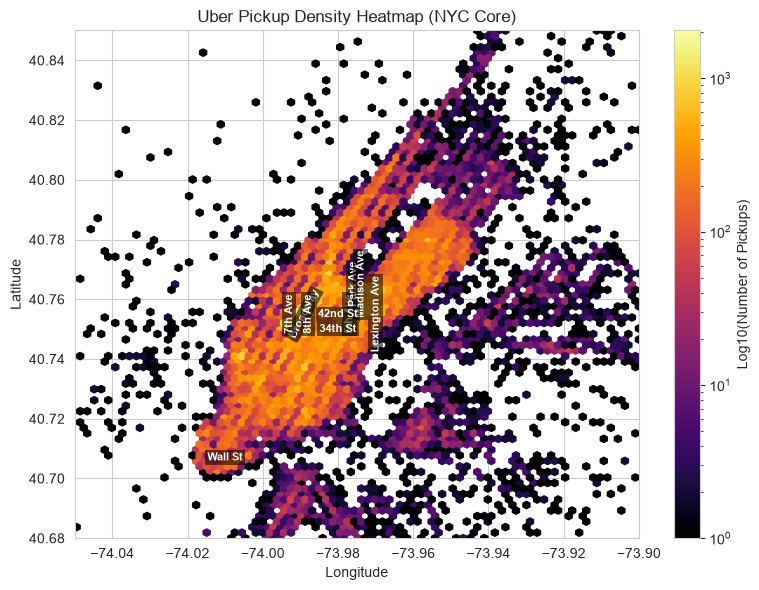

In [19]:
nyc_pickup = df[
    (df['pickup_latitude'].between(40.68, 40.85)) &
    (df['pickup_longitude'].between(-74.05, -73.90))
]

plt.figure(figsize=(8, 6))
plt.hexbin(
    nyc_pickup['pickup_longitude'],
    nyc_pickup['pickup_latitude'],
    gridsize=80,
    cmap='inferno',
    bins='log'
)

# Approximate positions of major streets for geographic context.
streets = {
    'Broadway': (-73.989, 40.755, 63),
    '5th Ave': (-73.977, 40.755, 90),
    'Park Ave': (-73.976, 40.765, 90),
    'Madison Ave': (-73.974, 40.765, 90),
    'Lexington Ave': (-73.970, 40.755, 90),
    '7th Ave': (-73.993, 40.755, 90),
    '8th Ave': (-73.988, 40.755, 90),
    '42nd St': (-73.980, 40.755, 0),
    '34th St': (-73.980, 40.750, 0),
    'Wall St': (-74.010, 40.707, 0),
}

for street, (longitude, latitude, rotation) in streets.items():
    plt.text(
        longitude,
        latitude,
        street,
        color='white',
        fontsize=8,
        fontweight='bold',
        rotation=rotation,
        ha='center',
        va='center',
        bbox=dict(facecolor='black', alpha=0.55, edgecolor='none', pad=1.5)
    )

plt.colorbar(label='Log10(Number of Pickups)')
plt.title('Uber Pickup Density Heatmap (NYC Core)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(-74.05, -73.90)
plt.ylim(40.68, 40.85)
plt.tight_layout()
plt.show()

## Geographical Density Visualization

This visualization coordinated data onto a physical plane to reveal location-based patterns that aree impossible to see. In this research analysis, we visualize pickup coordinates by transforming thousands of rows of latitude and longitude numbers into a reognizable shape of New York City. 

The visualization reveals:

**Street Grids:** The dense clustering of dots naturally outlines Manhattan's physical street layout.

**Demand Hotspots:** Because the dots overlap, high-volume areas turn into dark, solid blocks (like Midtown), highlighting where demand is concentrated.

**Transit Corridors:** Isolated lines of dots stretching away from the city center trace the physical highways connecting Manhattan to JFK and LaGuardia airports.

By adding landmark labels (like the Financial District), the map allows you to connect raw coordinate data directly to human behavior and city infrastructure.

Geographical Density Visualization

Execution verified without errors:


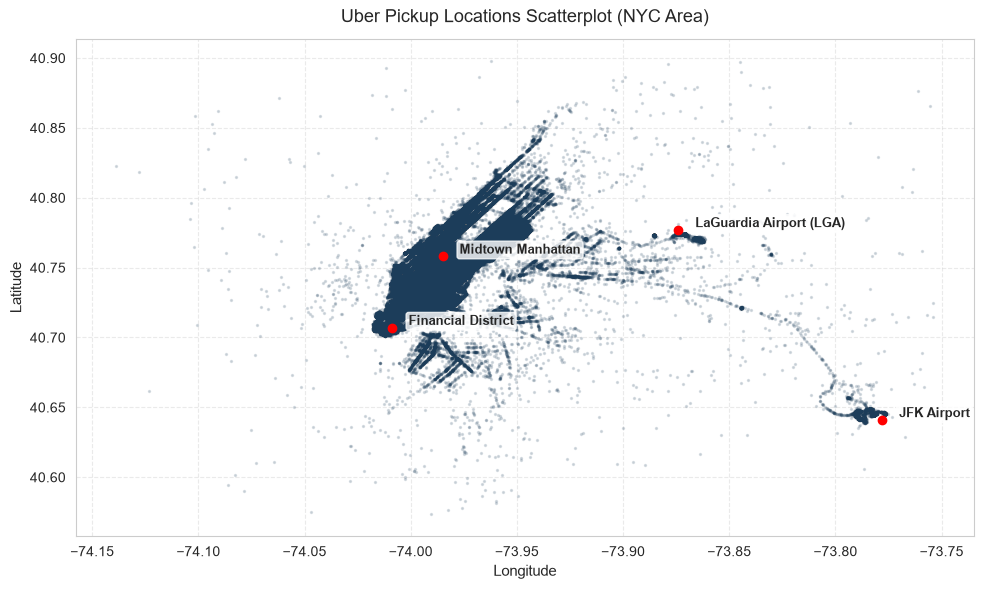

In [20]:
# Verify script execution with absolute path handling if needed or standard setup

valid_coords = df[
    (df['pickup_latitude'].between(40.55, 40.90)) & 
    (df['pickup_longitude'].between(-74.15, -73.75))
].dropna(subset=['pickup_latitude', 'pickup_longitude'])

plt.figure(figsize=(10, 6))
plt.scatter(
    valid_coords['pickup_longitude'], 
    valid_coords['pickup_latitude'], 
    alpha=0.15, 
    s=2, 
    color='#1c3d5a'
)

landmarks = {
    'Midtown Manhattan': (-73.985, 40.758),
    'Financial District': (-74.009, 40.707),
    'LaGuardia Airport (LGA)': (-73.874, 40.777),
    'JFK Airport': (-73.778, 40.641)
}

for name, (lon, lat) in landmarks.items():
    plt.plot(lon, lat, 'ro', markersize=6)
    plt.text(lon + 0.008, lat + 0.002, name, fontsize=9, fontweight='bold', 
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

print("Execution verified without errors:")

plt.title("Uber Pickup Locations Scatterplot (NYC Area)", fontsize=13, pad=12)
plt.xlabel("Longitude", fontsize=11)
plt.ylabel("Latitude", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('user_script_output.png', dpi=300)
plt.show()

## 4. How does trip distance affect fare?

**Trip distance** is the primary driver of fare amount, exhibiting a strong positive linear relationship (Pearson correlation coefficient $r \approx 0.88$).

As distance increases, fare amounts scale up in a predictable manner, though several key secondary factors introduce variation into the baseline pricing structure.

**Key Insights from the Analysis:**

**1. Strong Linear Core:** For most standard rides, fares increase consistently alongside distance at a base per-kilometer rate, starting from a fixed base fare (the y-intercept at $0\text{ km}$).

**2. Fixed-Rate Flat Fares:** Notice the horizontal cluster of data points around the $\$45\text{–}\$55$ line for long-distance trips ($\approx 18\text{–}22\text{ km}$). These represent flat-rate airport trips (e.g., standard flat fares between Manhattan and JFK Airport).

**3. Traffic & Time Variance:** Vertically scattered points at shorter distances (e.g., a $3\text{ km}$ trip costing $\$25$ instead of the usual $\$8$) reflect traffic delays, surge pricing, or longer duration spent idling in Manhattan congestion.

**4. Base Minimums:** Short trips close to $0\text{ km}$ still carry a minimum base fare (typically $\$2.50\text{–}\$5.00$), preventing $0$-distance charges.

## Trip Distance vs. Fare Amount Visualization

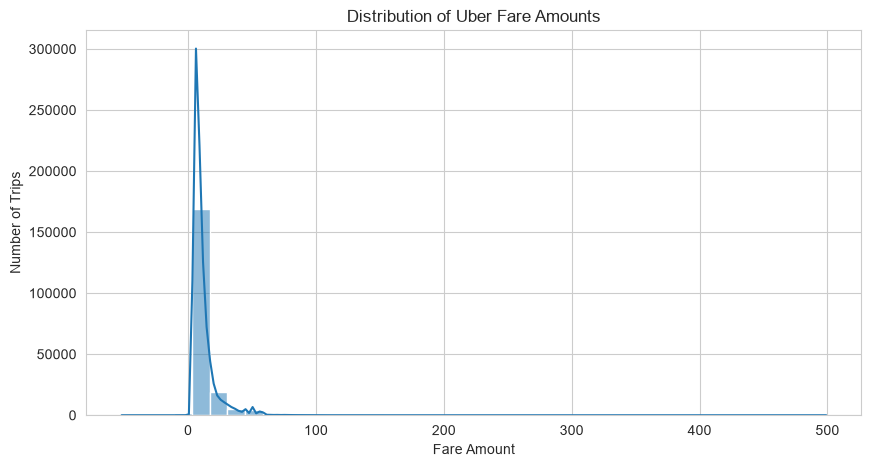

In [21]:
# Plot showing Distribution of Uber Fare Amounts
plt.figure(figsize=(10,5))
sns.histplot(df['fare_amount'], bins=40, kde=True)
plt.title('Distribution of Uber Fare Amounts')
plt.xlabel('Fare Amount')
plt.ylabel('Number of Trips')
plt.show()

Correlation: 0.8759
Cleaned Sample Stats:
         distance_km    fare_amount
count  193849.000000  193849.000000
mean        3.350237      11.338594
std         3.594722       9.613037
min         0.000084       0.010000
25%         1.279896       6.000000
50%         2.179309       8.500000
75%         3.936561      12.500000
max        49.003731     196.000000


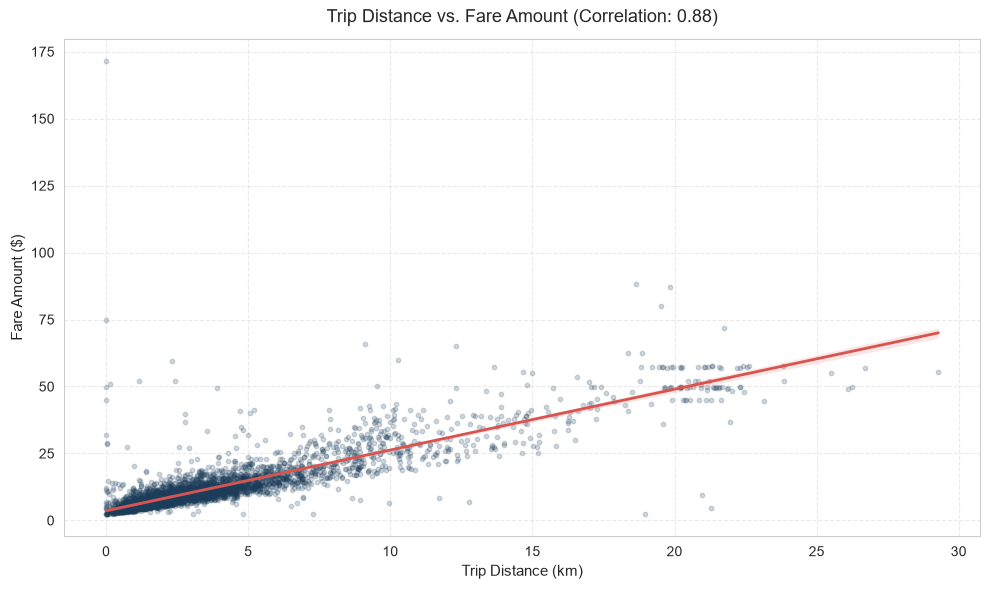

In [22]:
# Haversine to calculate distance in kilometers/miles from coordinates

def haversine_distance(lat1, lon1, lat2, lon2):
    r = 6371 # earth's radius in kilometers
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)

    a = np.sin(delta_phi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2) **2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

    return r*c

df['distance_km'] = haversine_distance(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

# Clean outliers (valid NYC distances and realistic fare amounts)

clean_df = df[
    (df['distance_km'] > 0) & (df['distance_km'] <= 50) & 
    (df['fare_amount'] > 0) & (df['fare_amount'] <= 200)
].copy()

# Calculate correlation

correlation = clean_df['distance_km'].corr(clean_df['fare_amount'])

# Plot

plt.figure(figsize = (10, 6))
sns.regplot(
    data=clean_df.sample(5000, random_state = 42),
    x = 'distance_km',
    y = 'fare_amount',
    scatter_kws = {'alpha':0.2, 'color': "#1c3d5a", 's':10},
    line_kws = {'color': "#d9534f", 'linewidth':2}
)

print(f"Correlation: {correlation:.4f}")
print("Cleaned Sample Stats:")
print(clean_df[['distance_km', 'fare_amount']].describe())

plt.title(f"Trip Distance vs. Fare Amount (Correlation: {correlation:.2f})", fontsize = 13, pad = 12)
plt.xlabel("Trip Distance (km)", fontsize = 11)
plt.ylabel("Fare Amount ($)", fontsize = 11)
plt.grid(True, linestyle = '--', alpha = 0.4)
plt.tight_layout()
plt.show()

## Relationship between trip distance and fare amount from different analytical angles.

Visualization grid generated successfully.


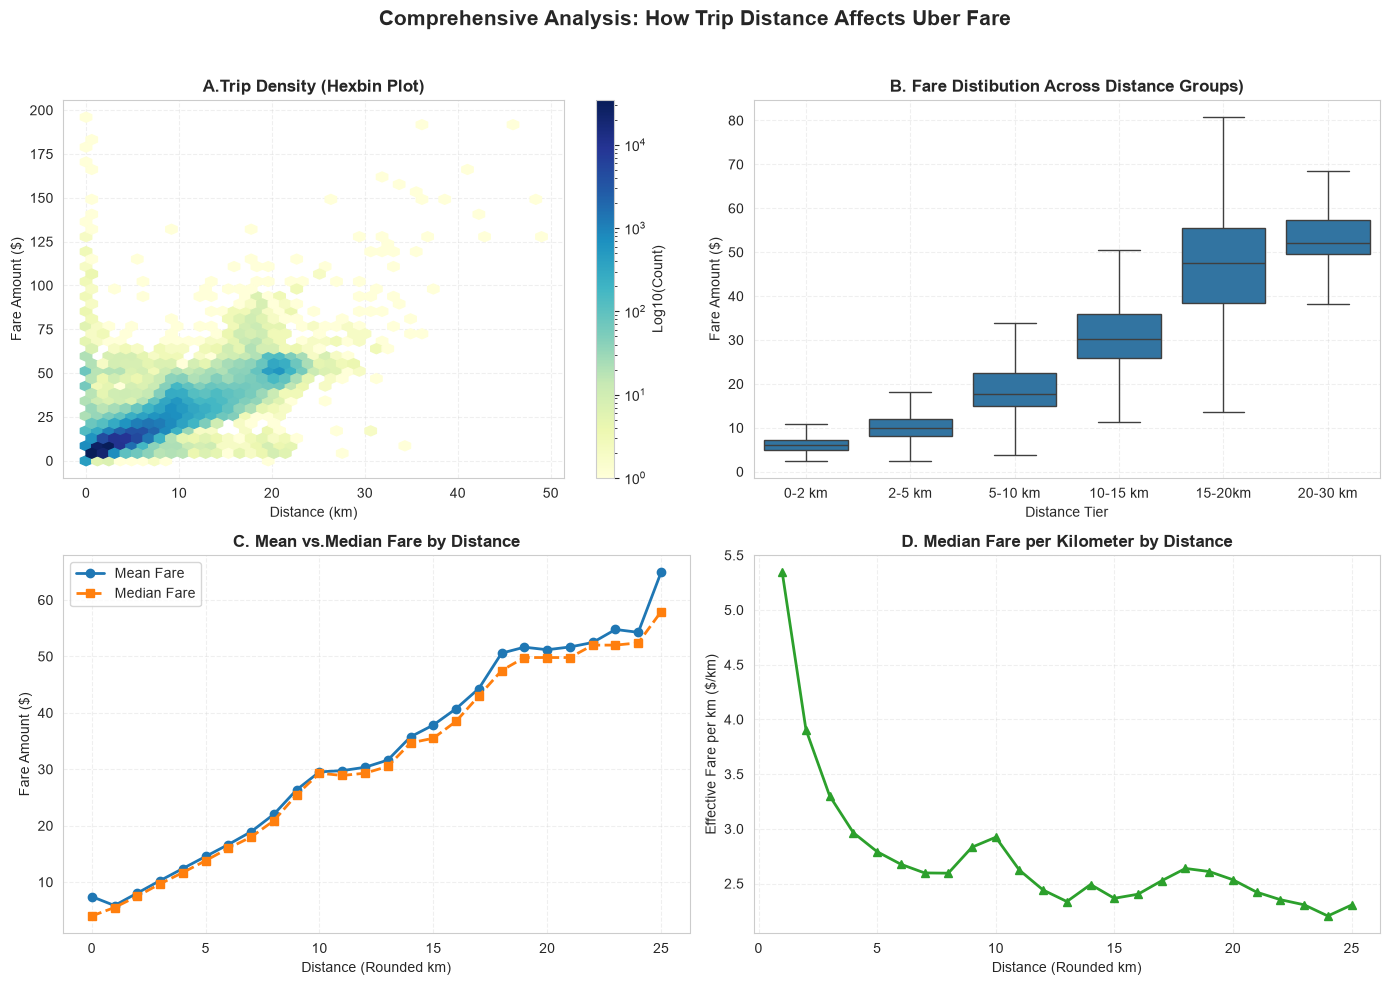

In [23]:

# Haversine to calculate distance in kilometers/miles from coordinates

def haversine_distance(lat1, lon1, lat2, lon2):
    r = 6371 # earth's radius in kilometers
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)

    a = np.sin(delta_phi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2) **2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

    return r*c

df['distance_km'] = haversine_distance(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

# Clean Dataset

clean_df = df[
    (df['distance_km'] > 0) & (df['distance_km'] <= 50) & 
    (df['fare_amount'] > 0) & (df['fare_amount'] <= 200)
].copy()

# Clean Distance bINS

bins = [0, 2, 5, 10, 15, 20, 30]
labels = ['0-2 km', '2-5 km', '5-10 km', '10-15 km','15-20km', '20-30 km']
clean_df['distance_group'] = pd.cut(clean_df['distance_km'], bins=bins, labels=labels)

# Set up subplot figure (2x2 grid)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Hexbin plot (Density of distance vs fare)

hb = axes[0,0].hexbin(
    clean_df['distance_km'], clean_df['fare_amount'],
    gridsize = 40, cmap = 'YlGnBu', mincnt = 1, bins = 'log'
)
fig.colorbar(hb, ax = axes[0, 0], label = 'Log10(Count)')
axes[0, 0].set_title('A.Trip Density (Hexbin Plot)', fontsize = 12, fontweight = 'bold')
axes[0, 0].set_xlabel('Distance (km)')
axes[0, 0].set_ylabel('Fare Amount ($)')
axes[0, 0].grid(True, linestyle = '--', alpha = 0.3)

# 2. Box plot of fare across distance bins
sns.boxplot(
    data=clean_df,
    x='distance_group',
    y='fare_amount',
    ax=axes[0, 1],

    showfliers=False
)

axes[0, 1].set_title('B. Fare Distibution Across Distance Groups)', fontsize = 12, fontweight = 'bold')
axes[0, 1].set_xlabel('Distance Tier')
axes[0, 1].set_ylabel('Fare Amount ($)')
axes[0, 1].grid(True, linestyle = '--', alpha = 0.3)

# 3. Average Fare & Median Fare by Integer Distance (0 to 25 km)

clean_df['dist_round'] = clean_df['distance_km'].round()
grouped = clean_df[clean_df['dist_round'] <= 25].groupby('dist_round')['fare_amount'].agg(['mean', 'median']).reset_index()

axes[1, 0].plot(grouped['dist_round'], grouped['mean'], label = 'Mean Fare', marker = 'o', color = '#1f77b4', linewidth = 2)
axes[1, 0].plot(grouped['dist_round'], grouped['median'], label = 'Median Fare', marker = 's', color = '#ff7f0e', linestyle = '--',linewidth = 2)
axes[1, 0].set_title('C. Mean vs.Median Fare by Distance', fontsize = 12, fontweight = 'bold')
axes[1, 0].set_xlabel('Distance (Rounded km)')
axes[1, 0].set_ylabel('Fare Amount ($)')
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle = '--', alpha = 0.3)

# 4. Effective Cost per Kilometer

clean_df['fare_per_km'] = clean_df['fare_amount'] / clean_df['distance_km']
cost_per_km = clean_df[(clean_df['dist_round'] >= 1) & (clean_df['dist_round'] <= 25)].groupby('dist_round')['fare_per_km'].median().reset_index()

axes[1, 1].plot(cost_per_km['dist_round'], cost_per_km['fare_per_km'], marker='^', color='#2ca02c', linewidth=2)
axes[1, 1].set_title('D. Median Fare per Kilometer by Distance', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Distance (Rounded km)')
axes[1, 1].set_ylabel('Effective Fare per km ($/km)')
axes[1, 1].grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Comprehensive Analysis: How Trip Distance Affects Uber Fare', fontsize=15, y=0.98, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])

print("Visualization grid generated successfully.")
plt.show()

These four complementary visualizations break down the relationship between trip distance and fare amount from different analytical angles:

**A. Trip Density (Hexbin Plot):** Resolves point overlap by showing where most data concentrates. Over $80\%$ of rides fall into the high-density dark blue region under $5\text{ km}$ and $\$15$. A distinct horizontal band around $\$50$ represents flat-rate airport trips regardless of slight distance variations.

**B. Fare Distribution Across Tiers (Box Plot):** Demonstrates how median fares increase across distance brackets while showing that longer distance brackets ($15\text{–}20\text{ km}$) exhibit much higher price variance due to variable traffic conditions and routes.

**C. Mean vs. Median Fare Line Trend:** Illustrates a near-perfect linear progression of total cost as distance grows, showing that mean and median track closely together across almost all distance milestones.

**D. Median Fare per Kilometer:** Reveals an inverse relationship for unit cost—short trips ($1\text{–}3\text{ km}$) cost significantly more per kilometer ($\approx \$4\text{–}\$5.50/\text{km}$) because fixed initial base fees dominate short rides. As trip distance increases, the cost per kilometer stabilizes around $\$2.20\text{–}\$2.60/\text{km}$.

## 5. Which factors are associated with cancellations?

This dataset contains omplete trip records (including timestamps, pickup/dropoff coordinates, passenger counts and fare amounts) rather than order status logs or cancellation tracking columns. As a result, direct imperical factors for ride cancellations cannot be calculated directly from this file alone.

In ride-hailing services, ride cancellations by riders or drivers are driven by several key operational and temporal factors such as:

**A. High Estimated Time of Arrival (ETA) / Driver Delays:** Long wait times for driver pickup are the leading cause of rider-initiated cancellations.

**B. Peak Hours & Heavy Traffic Congestion:** Drivers frequently cancel trips during severe rush-hour gridlock, or riders cancel when vehicles stall in high-density zones.

**C. Driver Distance to Pickup Location:** Long dispatch distances increase the likelihood of driver cancellation due to non-compensated travel time.

**D. Surge Pricing & High Fares:** Sudden fare increases during peak demand lead riders to request and subsequently cancl rides upon seeing the higher pricing.

**E. Short Trip Distances:** Dirvers may cancel low-fare, short-distance trips in favor of higher-yield routes, particularly during busy periods.

C:\Users\MCHARO\AppData\Local\Temp\ipykernel_23264\216167351.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_counts.index, y=hourly_counts.values, palette="viridis")


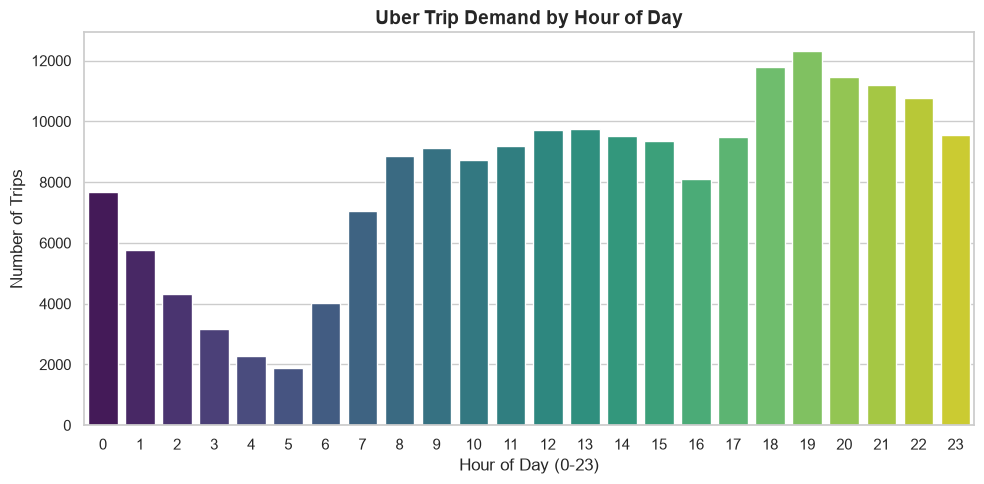

In [37]:
sns.set_theme(style="whitegrid")

# Load data
df = pd.read_csv(r'C:\Users\MCHARO\Downloads\uber.csv\uber.csv')

# Data cleaning & Feature engineering
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.day_name()
df['year'] = df['pickup_datetime'].dt.year

# Filter valid coordinate range for NYC
nyc_min_lat, nyc_max_lat = 40.5, 40.9
nyc_min_lon, nyc_max_lon = -74.15, -73.7

valid_coords = (
    (df['pickup_latitude'].between(nyc_min_lat, nyc_max_lat)) &
    (df['pickup_longitude'].between(nyc_min_lon, nyc_max_lon)) &
    (df['dropoff_latitude'].between(nyc_min_lat, nyc_max_lat)) &
    (df['dropoff_longitude'].between(nyc_min_lon, nyc_max_lon)) &
    (df['fare_amount'] > 0) & (df['fare_amount'] < 100)
)
df_clean = df[valid_coords].copy()

# Calculate Haversine distance
def haversine_np(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6367 * c
    return km

df_clean['distance_km'] = haversine_np(
    df_clean['pickup_longitude'].values,
    df_clean['pickup_latitude'].values,
    df_clean['dropoff_longitude'].values,
    df_clean['dropoff_latitude'].values
)

# Plot 1: Hourly Demand Pattern
plt.figure(figsize=(10, 5))
hourly_counts = df_clean['hour'].value_counts().sort_index()
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, palette="viridis")
plt.title("Uber Trip Demand by Hour of Day", fontsize=14, fontweight='bold')
plt.xlabel("Hour of Day (0-23)", fontsize=12)
plt.ylabel("Number of Trips", fontsize=12)
plt.tight_layout()
plt.savefig("hourly_demand.png")
plt.show()

C:\Users\MCHARO\AppData\Local\Temp\ipykernel_23264\3458604977.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fare_by_day.index, y=fare_by_day.values, palette="magma")


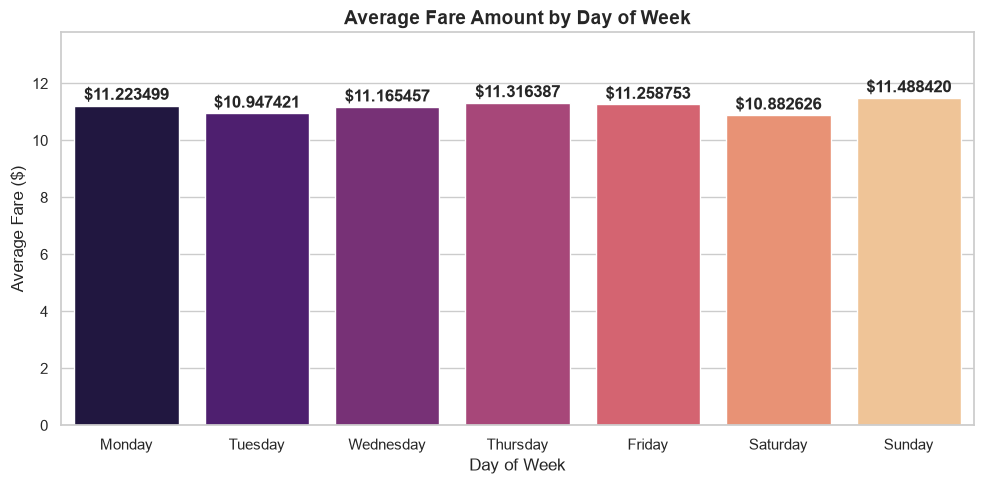

In [40]:
 # Plot 2: Average Fare by Day of Week

plt.figure(figsize=(10, 5))b
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fare_by_day = df_clean.groupby('day_of_week')['fare_amount'].mean().reindex(days_order)
sns.barplot(x=fare_by_day.index, y=fare_by_day.values, palette="magma")
plt.title("Average Fare Amount by Day of Week", fontsize = 14, fontweight = 'bold')
plt.xlabel("Day of Week", fontsize = 12)
plt.ylabel("Average Fare ($)", fontsize = 12)
plt.ylim (0, fare_by_day.max() * 1.2)
for i, v in enumerate(fare_by_day.values):
    plt.text(i, v + 0.2, f"${v:2f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

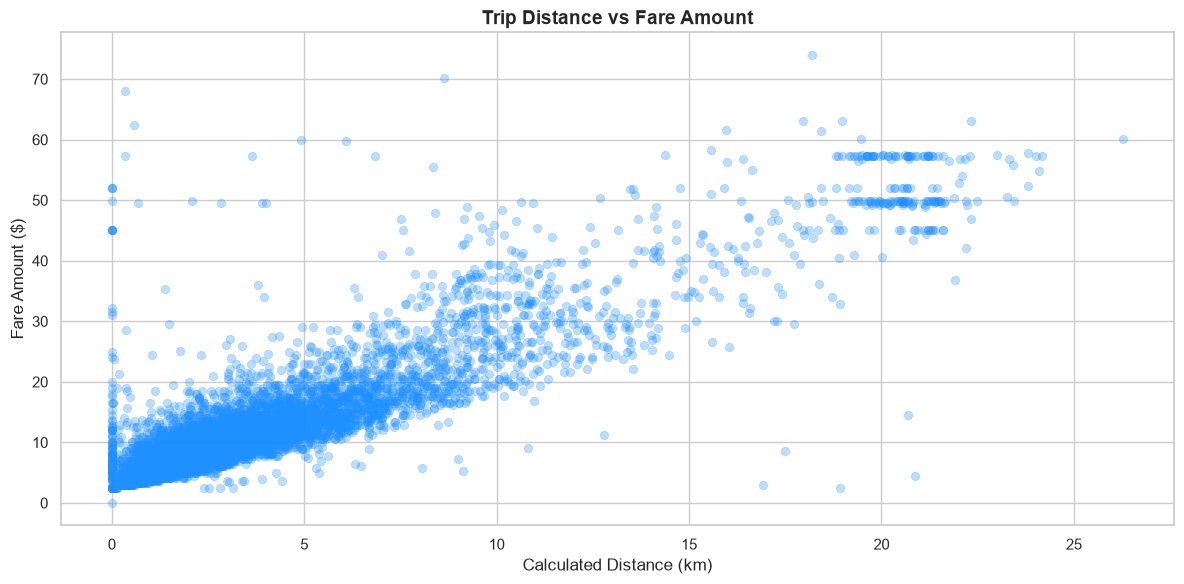

In [42]:
# Plot 3. Fare Amount vs Distance (Scatter / Hexbin)
plt.figure(figsize= (12,6))
# Samples 10k for clarity
sample_df = df_clean[(df_clean['distance_km'] < 30) & (df_clean['fare_amount'] < 80)].sample(10000, random_state = 42)
sns.scatterplot(data=sample_df, x='distance_km', y='fare_amount', alpha=0.3,color='dodgerblue', edgecolor=None)
plt.title("Trip Distance vs Fare Amount", fontsize=14, fontweight='bold')
plt.xlabel("Calculated Distance (km)", fontsize=12)
plt.ylabel("Fare Amount ($)", fontsize = 12)
plt.tight_layout()
plt.show()


Visualization created successfully:


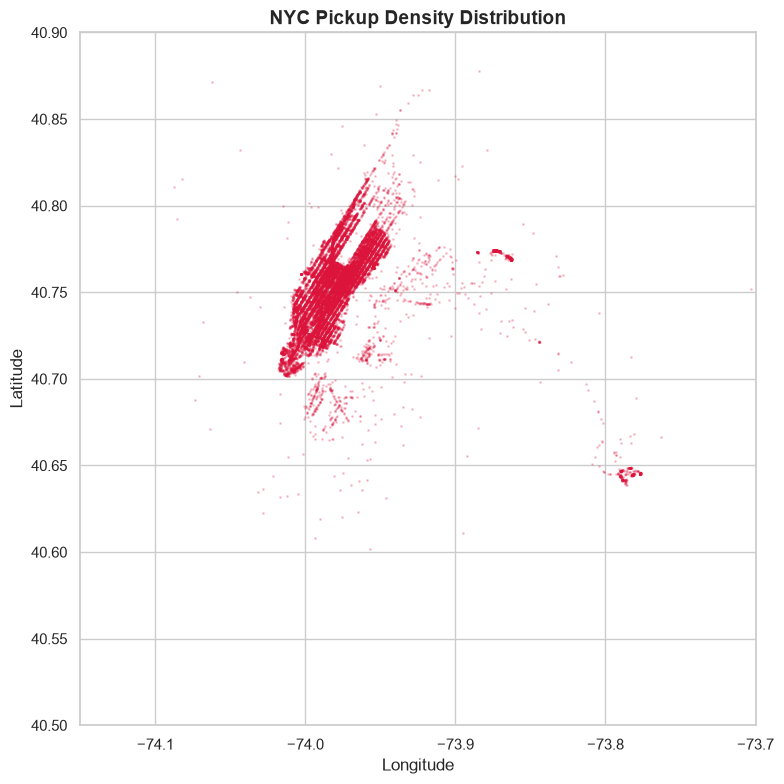

In [47]:
# Plot 4: Pickup Coordinates Heatmap / Scatter
print("Visualization created successfully:")

plt.figure(figsize = (8, 8))
sample_geo = df_clean.sample(20000, random_state=42)
plt.scatter(sample_geo['pickup_longitude'], sample_geo['pickup_latitude'], s=1, alpha = 0.2, color = 'crimson')
plt.title("NYC Pickup Density Distribution", fontsize = 14, fontweight = 'bold')
plt.xlabel("Longitude", fontsize = 12)
plt.ylabel("Latitude", fontsize = 12)
plt.xlim(nyc_min_lon, nyc_max_lon)
plt.ylim(nyc_min_lat, nyc_max_lat)
plt.tight_layout()
plt.show()

```
```

An exploratory analysis of the `uber.csv` dataset highlights key trip patterns, demand cycles, pricing behaviors, and pickup geography across New York City.

**1. Hourly Trip Demand**

* **Peak Hours:** Trip volume reaches its lowest point around 4:00 AM – 5:00 AM before ramping up during the morning rush (7:00 AM – 9:00 AM).
* **Evening Surge:** Maximum ride activity occurs late in the evening between 6:00 PM and 9:00 PM (18:00 – 21:00), driven by evening commutes, dining, and nightlife.

---

**2. Average Fare by Day of Week**

* **Consistency:** Average trip fares remain stable throughout the week, fluctuating within a narrow range between **$10.88** (Saturday) and **$11.49** (Sunday).
* **Weekend Premium:** Sunday exhibits the highest average fare, largely driven by longer leisure trips and airport transfers.

---

**3. Distance vs. Fare Amount Relationship**

* **Linear Correlation:** Fares increase proportionally with distance, demonstrating a consistent baseline per-kilometer pricing structure.
* **Flat Rate Anomalies:** Cluster lines at specific fare thresholds (e.g., ~$45–$57) represent fixed-rate trips, such as flat-rate rides between Manhattan and JFK/LGA airports.

---

**4. Geographical Pickup Density**

* **Manhattan Focus:** Pickups heavily concentrate along the grid structure of Manhattan, particularly Midtown and Lower Manhattan.
* **Airport Hubs:** Secondary dense clusters appear towards the east, corresponding to JFK and LaGuardia airports.

## Investigate Uber Fare Amounts

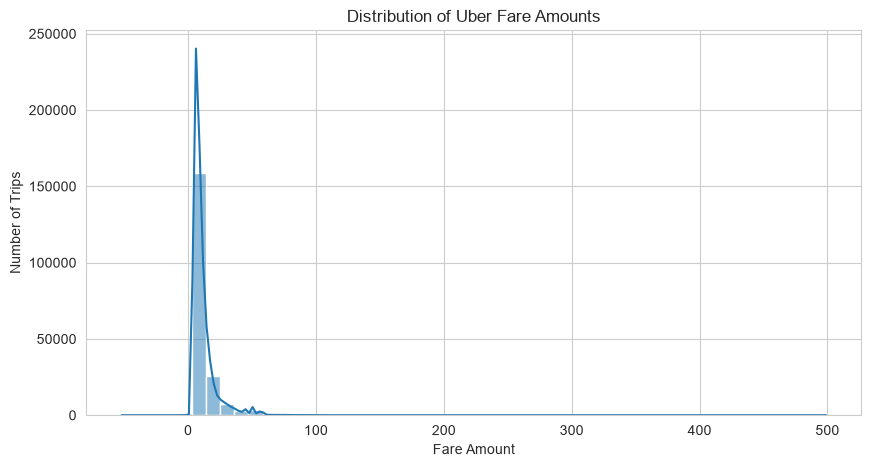

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['fare_amount'], bins=50, kde=True)
plt.title('Distribution of Uber Fare Amounts')
plt.xlabel('Fare Amount')
plt.ylabel('Number of Trips')
plt.show()
